# nb02 — Augmentation
Visualizes all 6 augmentation transforms with before/after panels.  


In [13]:
import sys, os

# Point to Project root AND to the augmentation subfolder
ROOT = os.path.abspath('..')
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, 'augmentation'))

from augmentor import (
    horizontal_flip, random_rotate, random_translate,
    brightness_jitter, gaussian_noise, random_crop_resize,
    TRANSFORM_NAMES, augment_dataset
)

PROCESSED_DIR = os.path.join('..', 'data', 'processed')
CLASS_NAMES   = sorted(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'])

## Load one sample per class

In [14]:
data   = np.load(os.path.join(PROCESSED_DIR, 'train.npz'), allow_pickle=True)
images = data['images']   # float32 (N, H, W, 3)
labels = data['labels']   # int32   (N,)

# Pick first image from each class
samples = {}
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    idxs = np.where(labels == cls_idx)[0]
    samples[cls_name] = images[idxs[0]]

print(f'Loaded {len(images)} training images across {len(CLASS_NAMES)} classes')
print(f'Image shape: {images[0].shape}')

Loaded 4200 training images across 6 classes
Image shape: (150, 150, 3)


## Before / After — all 6 transforms
Each row: one transform applied to the same source image.

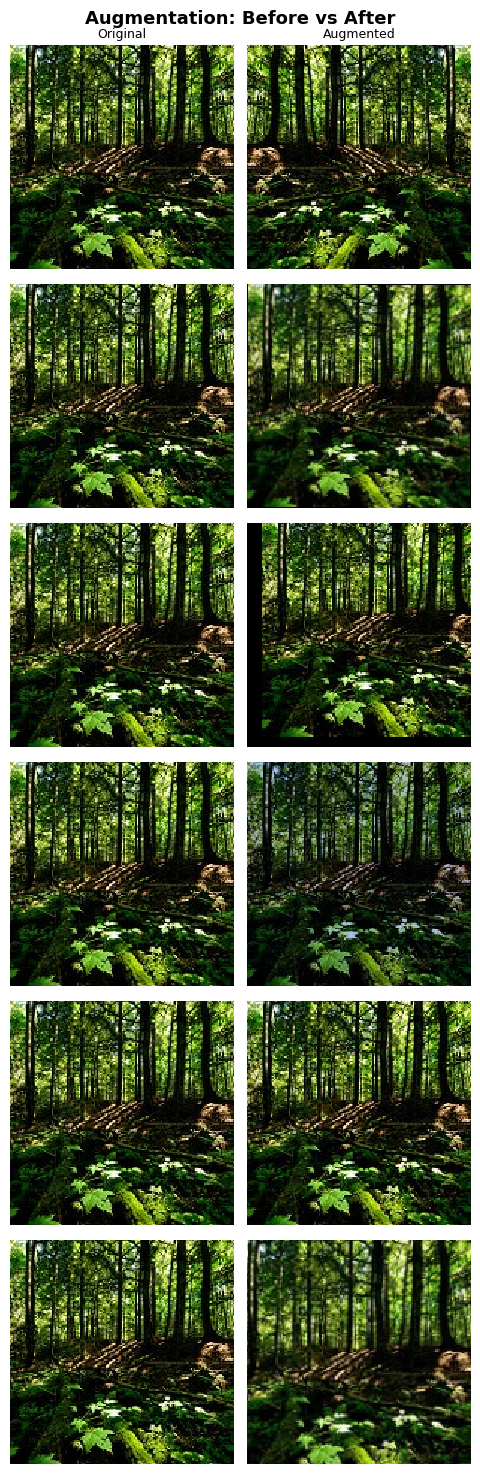

Saved → data/processed/augmentation_before_after.png


In [15]:
rng = np.random.default_rng(7)

# Use 'forest' as the demo image
demo_img = samples['forest']

transforms_fns = [
    ('Horizontal Flip',    lambda img: horizontal_flip(img)),
    ('Random Rotate ±15°', lambda img: random_rotate(img, np.random.default_rng(1))),
    ('Random Translate',   lambda img: random_translate(img, np.random.default_rng(2))),
    ('Brightness Jitter',  lambda img: brightness_jitter(img, np.random.default_rng(3))),
    ('Gaussian Noise',     lambda img: gaussian_noise(img, np.random.default_rng(4))),
    ('Random Crop+Resize', lambda img: random_crop_resize(img, np.random.default_rng(5))),
]

n_transforms = len(transforms_fns)
fig, axes = plt.subplots(n_transforms, 2, figsize=(5, 2.5 * n_transforms))
fig.suptitle('Augmentation: Before vs After', fontsize=13, fontweight='bold')

for row, (name, fn) in enumerate(transforms_fns):
    aug_img = fn(demo_img)

    axes[row, 0].imshow(np.clip(demo_img, 0, 1), interpolation='nearest')
    axes[row, 0].set_title('Original' if row == 0 else '', fontsize=9)
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=0, labelpad=80, va='center')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(np.clip(aug_img, 0, 1), interpolation='nearest')
    axes[row, 1].set_title('Augmented' if row == 0 else '', fontsize=9)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()
print('Saved → data/processed/augmentation_before_after.png')

## One transform × all 6 classes
Shows that augmentation works consistently across different scene types.

In [ ]:
fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(8, 3 * len(CLASS_NAMES)))
fig.suptitle('Random Crop+Resize — all classes', fontsize=13, fontweight='bold')

for row, cls_name in enumerate(CLASS_NAMES):
    orig = samples[cls_name]
    aug  = random_crop_resize(orig, np.random.default_rng(row))

    axes[row, 0].imshow(np.clip(orig, 0, 1))
    axes[row, 0].set_ylabel(cls_name, fontsize=10, rotation=0, labelpad=60, va='center')
    axes[row, 0].set_title('Original' if row == 0 else '', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(np.clip(aug, 0, 1))
    axes[row, 1].set_title('Augmented' if row == 0 else '', fontsize=10)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'augmentation_all_classes.png'),
            dpi=120, bbox_inches='tight')
plt.show()

## Run full augmentation (3× multiplier)
Generates `data/processed/train_augmented.npz` for use in feature extraction.

In [ ]:
from augmentor import load_and_augment_train

combined_images, combined_labels = load_and_augment_train(
    processed_dir=PROCESSED_DIR,
    multiplier=3,
    seed=42,
    save=True,
)

# Class balance check after augmentation
fig, ax = plt.subplots(figsize=(8, 4))
unique, counts = np.unique(combined_labels, return_counts=True)
ax.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue', edgecolor='white')
ax.set_title('Class Distribution — Combined Train (orig + augmented)', fontsize=12)
ax.set_ylabel('Count')
ax.set_xlabel('Class')
for i, c in enumerate(counts):
    ax.text(i, c + 20, str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'class_dist_augmented.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print(f'Final combined train size: {combined_images.shape[0]} images')